# Oxford5k + Paris6k Image Retrieval with Transfer-Learning CNN Embeddings

This Colab notebook downloads **Oxford5k** and **Paris6k** through the RevisitOP ground-truth files, combines them into one retrieval gallery, and evaluates CNN transfer-learning retrieval baselines with two pooling choices:

1. **ResNet50 + average pooling**
2. **ResNet50 + GeM pooling**
3. **EfficientNet-B0 + average pooling**
4. **EfficientNet-B0 + GeM pooling**
5. **VGG19 + average pooling**
6. **VGG19 + GeM pooling**

Important note: **GeM pooling is not a full model by itself.** It is a global pooling layer that replaces standard global average pooling in a CNN feature extractor. Therefore, it is reported as **backbone + GeM**, for example **ResNet50 + GeM**, not as a standalone model.

The notebook evaluates all available RevisitOP queries against the full combined Oxford5k + Paris6k gallery.


## 0. Install dependencies


In [1]:
!pip -q install -U timm tqdm pandas matplotlib psutil


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 14.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 whic

## 1. Imports and configuration


In [2]:
import os
import gc
import time
import math
import random
import pickle
import tarfile
import shutil
import subprocess
import threading
from pathlib import Path
from typing import Any, Dict, List, Tuple, Set

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

WORKDIR = Path("/content/oxford_paris_transfer_retrieval")
WORKDIR.mkdir(parents=True, exist_ok=True)

# Full dataset: all RevisitOP queries against the full combined Oxford+Paris gallery.
MAX_QUERY_IMAGES = None
MAX_DB_RANDOM_FILL = None

TOP_KS = (1, 5, 10)
F1_K = 10
BATCH_SIZE = 64
NUM_WORKERS = 0  # safest in Colab with PIL/OpenCV/mixed workloads

# GeM setting. p=3 is a common fixed default for retrieval descriptors.
GEM_P = 3.0
GEM_TRAIN_P = False

print("Workdir:", WORKDIR)


Device: cuda
Workdir: /content/oxford_paris_transfer_retrieval


## 2. Download Oxford5k + Paris6k and RevisitOP annotations

This uses direct image archives and RevisitOP `.pkl` ground-truth files. No dataset upload is required.


In [3]:
DATA_ROOT = WORKDIR / "revisitop_data"
DATASETS_ROOT = DATA_ROOT / "datasets"
DATASETS_ROOT.mkdir(parents=True, exist_ok=True)

DOWNLOAD_SOURCES = {
    "roxford5k": {
        "img_urls": ["https://www.robots.ox.ac.uk/~vgg/data/oxbuildings/oxbuild_images-v1.tgz"],
        "gnd_url": "https://cmp.felk.cvut.cz/revisitop/data/datasets/roxford5k/gnd_roxford5k.pkl",
    },
    "rparis6k": {
        "img_urls": [
            "https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_1-v1.tgz",
            "https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_2-v1.tgz",
        ],
        "gnd_url": "https://cmp.felk.cvut.cz/revisitop/data/datasets/rparis6k/gnd_rparis6k.pkl",
    },
}

def run_cmd(cmd: List[str]):
    print("$", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True)

def download_file(url: str, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        print(f"Already exists: {dst.name} ({dst.stat().st_size/1e6:.1f} MB)")
        return
    tmp = dst.with_suffix(dst.suffix + ".tmp")
    if tmp.exists():
        tmp.unlink()
    run_cmd(["wget", "-c", "--tries=5", "--timeout=60", url, "-O", str(tmp)])
    tmp.rename(dst)

def safe_extract_flat_tgz(tgz_path: Path, dst_dir: Path):
    """Extract a tar.gz archive and move only files into dst_dir. Prevents path traversal."""
    marker = dst_dir / (tgz_path.name + ".extracted")
    if marker.exists():
        print(f"Already extracted: {tgz_path.name}")
        return

    dst_dir.mkdir(parents=True, exist_ok=True)
    tmp_dir = dst_dir / ("_tmp_extract_" + tgz_path.stem.replace(".", "_"))
    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)
    tmp_dir.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {tgz_path.name} ...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        base = tmp_dir.resolve()
        for member in tar.getmembers():
            target = (tmp_dir / member.name).resolve()
            if not str(target).startswith(str(base)):
                raise RuntimeError(f"Blocked unsafe tar path: {member.name}")
        tar.extractall(tmp_dir)

    moved = 0
    for f in tmp_dir.rglob("*"):
        if f.is_file():
            out = dst_dir / f.name
            if not out.exists():
                shutil.move(str(f), str(out))
                moved += 1
    shutil.rmtree(tmp_dir)
    marker.write_text("ok")
    print(f"Moved {moved} image files into {dst_dir}")

def as_int_list(x: Any) -> List[int]:
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.astype(int).tolist()
    if isinstance(x, (list, tuple, set)):
        return [int(v) for v in x]
    try:
        return [int(v) for v in list(x)]
    except Exception:
        return []

def download_revisitop_dataset(dataset: str):
    spec = DOWNLOAD_SOURCES[dataset]
    dataset_dir = DATASETS_ROOT / dataset
    jpg_dir = dataset_dir / "jpg"
    jpg_dir.mkdir(parents=True, exist_ok=True)

    for url in spec["img_urls"]:
        archive_path = jpg_dir / Path(url).name
        download_file(url, archive_path)
        safe_extract_flat_tgz(archive_path, jpg_dir)

    gnd_path = dataset_dir / f"gnd_{dataset}.pkl"
    download_file(spec["gnd_url"], gnd_path)
    return dataset_dir, jpg_dir, gnd_path

def load_revisitop_cfg(dataset: str):
    dataset_dir, jpg_dir, gnd_path = download_revisitop_dataset(dataset)
    with open(gnd_path, "rb") as f:
        cfg = pickle.load(f)
    cfg["dataset"] = dataset
    cfg["dir_images"] = str(jpg_dir)
    cfg["ext"] = ".jpg"
    cfg["qext"] = ".jpg"
    cfg["n"] = len(cfg["imlist"])
    cfg["nq"] = len(cfg["qimlist"])
    return cfg

def image_path_from_name(cfg: dict, name: str, query: bool = False) -> str:
    ext = cfg["qext"] if query else cfg["ext"]
    return str(Path(cfg["dir_images"]) / f"{name}{ext}")

def records_from_cfg(cfg: dict, db_offset: int):
    dataset = cfg["dataset"]
    db_records = []
    for i, name in enumerate(cfg["imlist"]):
        db_records.append({
            "dataset": dataset,
            "source_index": i,
            "global_index": db_offset + i,
            "name": name,
            "filename": f"{dataset}_{name}.jpg",
            "image_path": image_path_from_name(cfg, name, query=False),
        })

    q_records = []
    for qi, name in enumerate(cfg["qimlist"]):
        g = cfg["gnd"][qi]
        q_records.append({
            "dataset": dataset,
            "source_query_index": qi,
            "name": name,
            "filename": f"{dataset}_query_{qi:03d}_{name}.jpg",
            "image_path": image_path_from_name(cfg, name, query=True),
            "bbx": g.get("bbx", None),
            "easy": [db_offset + i for i in as_int_list(g.get("easy", []))],
            "hard": [db_offset + i for i in as_int_list(g.get("hard", []))],
            "medium": [db_offset + i for i in as_int_list(g.get("medium", []))],
            "junk": [db_offset + i for i in as_int_list(g.get("junk", []))],
        })
    return db_records, q_records

all_db_records = []
all_q_records = []
offset = 0
cfgs = {}
for dataset in ["roxford5k", "rparis6k"]:
    print("\n" + "=" * 80)
    print(f"Loading {dataset}")
    cfg = load_revisitop_cfg(dataset)
    cfgs[dataset] = cfg
    db_part, q_part = records_from_cfg(cfg, db_offset=offset)
    all_db_records.extend(db_part)
    all_q_records.extend(q_part)
    offset += len(db_part)
    print(f"{dataset}: {len(db_part)} DB images, {len(q_part)} queries")

# Standard variable names used later.
db_records = all_db_records
q_records = all_q_records

missing = [r["image_path"] for r in (db_records[:5] + q_records[:5]) if not Path(r["image_path"]).exists()]
if missing:
    raise FileNotFoundError("Some image paths are missing after extraction, e.g. " + str(missing[:3]))

print("\nCombined database images:", len(db_records))
print("Combined query images:", len(q_records))
print("Example DB record:", db_records[0])
print("Example query record:", {k: v for k, v in q_records[0].items() if k != "image_path"})


Loading roxford5k
$ wget -c --tries=5 --timeout=60 https://www.robots.ox.ac.uk/~vgg/data/oxbuildings/oxbuild_images-v1.tgz -O /content/oxford_paris_transfer_retrieval/revisitop_data/datasets/roxford5k/jpg/oxbuild_images-v1.tgz.tmp
Extracting oxbuild_images-v1.tgz ...


/tmp/ipykernel_1574/1606461544.py:57: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(tmp_dir)


Moved 5063 image files into /content/oxford_paris_transfer_retrieval/revisitop_data/datasets/roxford5k/jpg
$ wget -c --tries=5 --timeout=60 https://cmp.felk.cvut.cz/revisitop/data/datasets/roxford5k/gnd_roxford5k.pkl -O /content/oxford_paris_transfer_retrieval/revisitop_data/datasets/roxford5k/gnd_roxford5k.pkl.tmp
roxford5k: 4993 DB images, 70 queries

Loading rparis6k
$ wget -c --tries=5 --timeout=60 https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_1-v1.tgz -O /content/oxford_paris_transfer_retrieval/revisitop_data/datasets/rparis6k/jpg/paris_1-v1.tgz.tmp
Extracting paris_1-v1.tgz ...


/tmp/ipykernel_1574/1606461544.py:57: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(tmp_dir)


Moved 3190 image files into /content/oxford_paris_transfer_retrieval/revisitop_data/datasets/rparis6k/jpg
$ wget -c --tries=5 --timeout=60 https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_2-v1.tgz -O /content/oxford_paris_transfer_retrieval/revisitop_data/datasets/rparis6k/jpg/paris_2-v1.tgz.tmp
Extracting paris_2-v1.tgz ...


/tmp/ipykernel_1574/1606461544.py:57: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(tmp_dir)


Moved 3222 image files into /content/oxford_paris_transfer_retrieval/revisitop_data/datasets/rparis6k/jpg
$ wget -c --tries=5 --timeout=60 https://cmp.felk.cvut.cz/revisitop/data/datasets/rparis6k/gnd_rparis6k.pkl -O /content/oxford_paris_transfer_retrieval/revisitop_data/datasets/rparis6k/gnd_rparis6k.pkl.tmp
rparis6k: 6322 DB images, 70 queries

Combined database images: 11315
Combined query images: 140
Example DB record: {'dataset': 'roxford5k', 'source_index': 0, 'global_index': 0, 'name': 'ashmolean_000283', 'filename': 'roxford5k_ashmolean_000283.jpg', 'image_path': '/content/oxford_paris_transfer_retrieval/revisitop_data/datasets/roxford5k/jpg/ashmolean_000283.jpg'}
Example query record: {'dataset': 'roxford5k', 'source_query_index': 0, 'name': 'all_souls_000013', 'filename': 'roxford5k_query_000_all_souls_000013.jpg', 'bbx': [136.5, 34.1, 648.5, 955.7], 'easy': [30, 69, 296, 324, 581, 623, 685, 691, 736, 801, 953, 1125, 1232, 1318, 1392, 1520, 1581, 1619, 1643, 1688, 1707, 1754

## 3. Build evaluation set and materialize cropped query images

The combined gallery contains every Oxford5k and Paris6k database image. Query images are cropped with the official query bounding boxes when available.


In [4]:
def to_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.astype(int).tolist()
    if isinstance(x, (list, tuple, set)):
        return [int(v) for v in x]
    try:
        return [int(v) for v in list(x)]
    except Exception:
        return []

def get_relevant_and_junk(q_example):
    easy = to_list(q_example.get("easy", []))
    hard = to_list(q_example.get("hard", []))
    medium = to_list(q_example.get("medium", []))
    junk = to_list(q_example.get("junk", []))
    relevant = sorted(set(easy + hard + medium))
    junk = sorted(set(junk))
    return relevant, junk

def choose_eval_subset(q_records, db_records, max_queries=None, max_random_fill=None):
    n_queries = len(q_records) if max_queries is None else min(max_queries, len(q_records))
    q_indices = list(range(n_queries))

    must_have = set()
    for qi in q_indices:
        rel, junk = get_relevant_and_junk(q_records[qi])
        must_have.update(rel)
        must_have.update(junk)

    all_db_indices = set(range(len(db_records)))
    remaining = sorted(all_db_indices - must_have)
    rng = np.random.default_rng(SEED)

    if max_random_fill is None:
        random_fill = remaining
    else:
        fill_n = min(max_random_fill, len(remaining))
        random_fill = rng.choice(remaining, size=fill_n, replace=False).astype(int).tolist()

    db_indices = sorted(must_have.union(set(random_fill)))
    old_to_new = {old: new for new, old in enumerate(db_indices)}

    gt = []
    for source_qi in q_indices:
        rel, junk = get_relevant_and_junk(q_records[source_qi])
        rel_new = sorted(old_to_new[i] for i in rel if i in old_to_new)
        junk_new = sorted(old_to_new[i] for i in junk if i in old_to_new)
        gt.append({
            "source_query_index": source_qi,
            "relevant": set(rel_new),
            "junk": set(junk_new),
            "num_relevant_original": len(rel),
            "num_relevant_in_subset": len(rel_new),
        })
    return q_indices, db_indices, gt

q_indices, db_indices, query_gt = choose_eval_subset(
    q_records, db_records,
    max_queries=MAX_QUERY_IMAGES,
    max_random_fill=MAX_DB_RANDOM_FILL,
)
print(f"Selected queries: {len(q_indices)} / {len(q_records)}")
print(f"Selected database images: {len(db_indices)} / {len(db_records)}")
print("Relevant images in subset, first 5 queries:", [g["num_relevant_in_subset"] for g in query_gt[:5]])

def clean_name(name, fallback):
    if not name:
        return fallback
    return str(name).replace("/", "_").replace("\\", "_").replace(" ", "_")

def crop_query_if_bbox(img: Image.Image, ex: dict) -> Image.Image:
    bbx = ex.get("bbx", None)
    if bbx is None:
        return img
    bbx = to_list(bbx)
    if len(bbx) != 4:
        return img
    x1, y1, x2, y2 = [float(v) for v in bbx]
    w, h = img.size
    x1 = max(0, min(w - 1, x1))
    x2 = max(1, min(w, x2))
    y1 = max(0, min(h - 1, y1))
    y2 = max(1, min(h, y2))
    if x2 <= x1 or y2 <= y1:
        return img
    return img.crop((x1, y1, x2, y2))

def materialize_images(records, indices, out_dir: Path, prefix="img", crop_queries=False):
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    meta = []
    for local_i, source_i in enumerate(tqdm(indices, desc=f"Saving {prefix}")):
        ex = records[int(source_i)]
        img = Image.open(ex["image_path"]).convert("RGB")
        if crop_queries:
            img = crop_query_if_bbox(img, ex)
        filename = clean_name(ex.get("filename", None), f"{prefix}_{source_i}.jpg")
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            filename += ".jpg"
        path = out_dir / f"{local_i:05d}_{filename}"
        if not path.exists():
            img.save(path, quality=95)
        paths.append(str(path))
        meta.append(dict(ex))
    return paths, meta

DB_DIR = WORKDIR / "db_images"
Q_DIR = WORKDIR / "query_images"

db_paths, db_meta = materialize_images(db_records, db_indices, DB_DIR, prefix="db", crop_queries=False)
q_paths, q_meta = materialize_images(q_records, q_indices, Q_DIR, prefix="query", crop_queries=True)

print("First DB path:", db_paths[0])
print("First query path:", q_paths[0])

Selected queries: 140 / 140
Selected database images: 11315 / 11315
Relevant images in subset, first 5 queries: [103, 103, 103, 103, 103]


Saving db:   0%|          | 0/11315 [00:00<?, ?it/s]

Saving query:   0%|          | 0/140 [00:00<?, ?it/s]

First DB path: /content/oxford_paris_transfer_retrieval/db_images/00000_roxford5k_ashmolean_000283.jpg
First query path: /content/oxford_paris_transfer_retrieval/query_images/00000_roxford5k_query_000_all_souls_000013.jpg


## 4. Retrieval metrics and resource tracking

mAP is the primary ranking metric. P@K, R@K, and F1@10 describe top-ranking retrieval quality. Runtime and memory are measured per method.


In [5]:
def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norm, eps)

def ranked_indices_without_junk(scores_1d: np.ndarray, junk: Set[int]) -> List[int]:
    # Stable sort makes tied scores deterministic.
    order = np.argsort(-scores_1d, kind="mergesort")
    return [int(i) for i in order if int(i) not in junk]

def average_precision_from_scores(scores: np.ndarray, relevant: Set[int], junk: Set[int]) -> float:
    if len(relevant) == 0:
        return np.nan
    order = ranked_indices_without_junk(scores, junk)
    hits = 0
    sum_prec = 0.0
    for rank, idx in enumerate(order, start=1):
        if idx in relevant:
            hits += 1
            sum_prec += hits / rank
            if hits == len(relevant):
                break
    return sum_prec / len(relevant)

def precision_at_k_from_scores(scores: np.ndarray, relevant: Set[int], junk: Set[int], k: int) -> float:
    if len(relevant) == 0:
        return np.nan
    kept = ranked_indices_without_junk(scores, junk)[:k]
    if not kept:
        return np.nan
    return sum(1 for idx in kept if idx in relevant) / len(kept)

def recall_at_k_from_scores(scores: np.ndarray, relevant: Set[int], junk: Set[int], k: int) -> float:
    if len(relevant) == 0:
        return np.nan
    kept = ranked_indices_without_junk(scores, junk)[:k]
    hits = sum(1 for idx in kept if idx in relevant)
    return hits / len(relevant)

def f1_at_k_from_scores(scores: np.ndarray, relevant: Set[int], junk: Set[int], k: int) -> float:
    p = precision_at_k_from_scores(scores, relevant, junk, k)
    r = recall_at_k_from_scores(scores, relevant, junk, k)
    if np.isnan(p) or np.isnan(r) or (p + r) == 0:
        return 0.0
    return 2 * p * r / (p + r)

def evaluate_scores_matrix(name: str, scores: np.ndarray, query_gt: List[dict], top_ks=TOP_KS, f1_k=F1_K) -> dict:
    aps = []
    pks = {k: [] for k in top_ks}
    rks = {k: [] for k in top_ks}
    f1s = []

    for qi, gt in enumerate(query_gt):
        rel = gt["relevant"]
        junk = gt["junk"]
        aps.append(average_precision_from_scores(scores[qi], rel, junk))
        f1s.append(f1_at_k_from_scores(scores[qi], rel, junk, f1_k))
        for k in top_ks:
            pks[k].append(precision_at_k_from_scores(scores[qi], rel, junk, k))
            rks[k].append(recall_at_k_from_scores(scores[qi], rel, junk, k))

    out = {"method": name, "mAP": float(np.nanmean(aps))}
    for k in top_ks:
        out[f"P@{k}"] = float(np.nanmean(pks[k]))
    for k in top_ks:
        out[f"R@{k}"] = float(np.nanmean(rks[k]))
    out[f"F1@{f1_k}"] = float(np.nanmean(f1s))
    return out

def evaluate_embeddings(name: str, q_emb: np.ndarray, db_emb: np.ndarray, query_gt: List[dict]) -> Tuple[dict, np.ndarray]:
    q_emb = l2_normalize(q_emb)
    db_emb = l2_normalize(db_emb)
    scores = q_emb @ db_emb.T
    return evaluate_scores_matrix(name, scores, query_gt), scores

class ResourceTracker:
    """Wall-time + approximate CPU/GPU peak memory tracker."""
    def __init__(self, sample_interval: float = 0.25):
        self.sample_interval = sample_interval
        self.process = psutil.Process(os.getpid())
        self._stop = threading.Event()
        self._thread = None
        self.peak_rss_bytes = 0
        self.peak_gpu_allocated_bytes = 0
        self.peak_gpu_reserved_bytes = 0
        self.seconds = 0.0

    def _sample_once(self):
        try:
            self.peak_rss_bytes = max(self.peak_rss_bytes, self.process.memory_info().rss)
        except Exception:
            pass
        if torch.cuda.is_available():
            try:
                self.peak_gpu_allocated_bytes = max(
                    self.peak_gpu_allocated_bytes,
                    torch.cuda.max_memory_allocated(),
                    torch.cuda.memory_allocated(),
                )
                self.peak_gpu_reserved_bytes = max(
                    self.peak_gpu_reserved_bytes,
                    torch.cuda.max_memory_reserved(),
                    torch.cuda.memory_reserved(),
                )
            except Exception:
                pass

    def _sample_loop(self):
        while not self._stop.is_set():
            self._sample_once()
            time.sleep(self.sample_interval)

    def __enter__(self):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        self._sample_once()
        self.t0 = time.perf_counter()
        self._thread = threading.Thread(target=self._sample_loop, daemon=True)
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc, tb):
        self.seconds = time.perf_counter() - self.t0
        self._sample_once()
        self._stop.set()
        if self._thread is not None:
            self._thread.join(timeout=1.0)
        self._sample_once()

    @property
    def peak_ram_mb(self) -> float:
        return self.peak_rss_bytes / (1024 ** 2)

    @property
    def peak_gpu_allocated_mb(self) -> float:
        return self.peak_gpu_allocated_bytes / (1024 ** 2)

    @property
    def peak_gpu_reserved_mb(self) -> float:
        return self.peak_gpu_reserved_bytes / (1024 ** 2)

def add_runtime_metrics(result: dict, tracker: ResourceTracker, n_queries: int) -> dict:
    result["seconds"] = float(tracker.seconds)
    result["inference_latency_ms_per_query"] = float(1000 * tracker.seconds / max(1, n_queries))
    result["peak_ram_mb"] = float(tracker.peak_ram_mb)
    result["peak_gpu_allocated_mb"] = float(tracker.peak_gpu_allocated_mb)
    result["peak_gpu_reserved_mb"] = float(tracker.peak_gpu_reserved_mb)
    result["memory_usage_mb"] = float(tracker.peak_ram_mb + tracker.peak_gpu_reserved_mb)
    return result

## 5. Model wrappers: ResNet50, EfficientNet-B0, and VGG19 with AvgPool or GeM Pooling

All models use pretrained ImageNet weights and act as frozen feature extractors. This is transfer learning in the feature-extraction sense: no Oxford/Paris labels are used to fine-tune the models.

For fairness, each backbone is evaluated twice:

- once with standard global average pooling;
- once with GeM pooling.

In [6]:
class ImagePathDataset(Dataset):
    def __init__(self, paths: List[str], transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img

class GeM(nn.Module):
    """
    Generalized Mean Pooling layer.
    GeM is a pooling layer, not a standalone model.
    With p=1 it becomes average pooling. Larger p emphasizes stronger activations.
    """
    def __init__(self, p: float = 3.0, eps: float = 1e-6, train_p: bool = False):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p, requires_grad=train_p)
        self.eps = eps

    def forward(self, x):
        # GeM assumes non-negative feature activations. clamp() also avoids invalid powers.
        x = x.clamp(min=self.eps).pow(self.p)
        x = F.avg_pool2d(x, kernel_size=(x.size(-2), x.size(-1)))
        return x.pow(1.0 / self.p)

class CNNBackbonePoolingExtractor(nn.Module):
    """
    Generic CNN retrieval feature extractor:
    image -> convolutional feature map -> global pooling -> flattened descriptor.

    pool_type:
        "avg" = global average pooling
        "gem" = generalized mean pooling
    """
    def __init__(self, features: nn.Module, out_dim: int, pool_type: str = "avg", gem_p: float = 3.0, train_p: bool = False):
        super().__init__()
        self.features = features
        self.out_dim = out_dim
        if pool_type == "avg":
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
        elif pool_type == "gem":
            self.pool = GeM(p=gem_p, train_p=train_p)
        else:
            raise ValueError(f"Unsupported pool_type: {pool_type}")

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)

def make_resnet50_avgpool():
    weights = models.ResNet50_Weights.DEFAULT
    base = models.resnet50(weights=weights)
    features = nn.Sequential(
        base.conv1, base.bn1, base.relu, base.maxpool,
        base.layer1, base.layer2, base.layer3, base.layer4,
    )
    model = CNNBackbonePoolingExtractor(features, out_dim=base.fc.in_features, pool_type="avg")
    transform = weights.transforms()
    return "ResNet50 + AvgPool transfer embeddings", model, transform

def make_resnet50_gem():
    weights = models.ResNet50_Weights.DEFAULT
    base = models.resnet50(weights=weights)
    features = nn.Sequential(
        base.conv1, base.bn1, base.relu, base.maxpool,
        base.layer1, base.layer2, base.layer3, base.layer4,
    )
    model = CNNBackbonePoolingExtractor(
        features, out_dim=base.fc.in_features, pool_type="gem", gem_p=GEM_P, train_p=GEM_TRAIN_P
    )
    transform = weights.transforms()
    return f"ResNet50 + GeM(p={GEM_P:g}) transfer embeddings", model, transform

def make_efficientnet_b0_avgpool():
    weights = models.EfficientNet_B0_Weights.DEFAULT
    base = models.efficientnet_b0(weights=weights)
    # base.features outputs the final convolutional feature map before avgpool/classifier.
    out_dim = base.classifier[1].in_features
    model = CNNBackbonePoolingExtractor(base.features, out_dim=out_dim, pool_type="avg")
    transform = weights.transforms()
    return "EfficientNet-B0 + AvgPool transfer embeddings", model, transform

def make_efficientnet_b0_gem():
    weights = models.EfficientNet_B0_Weights.DEFAULT
    base = models.efficientnet_b0(weights=weights)
    out_dim = base.classifier[1].in_features
    model = CNNBackbonePoolingExtractor(
        base.features, out_dim=out_dim, pool_type="gem", gem_p=GEM_P, train_p=GEM_TRAIN_P
    )
    transform = weights.transforms()
    return f"EfficientNet-B0 + GeM(p={GEM_P:g}) transfer embeddings", model, transform

def make_vgg19_avgpool():
    weights = models.VGG19_Weights.DEFAULT
    base = models.vgg19(weights=weights)
    # VGG19 convolutional backbone has 512 output channels.
    model = CNNBackbonePoolingExtractor(base.features, out_dim=512, pool_type="avg")
    transform = weights.transforms()
    return "VGG19 + AvgPool transfer embeddings", model, transform

def make_vgg19_gem():
    weights = models.VGG19_Weights.DEFAULT
    base = models.vgg19(weights=weights)
    model = CNNBackbonePoolingExtractor(
        base.features, out_dim=512, pool_type="gem", gem_p=GEM_P, train_p=GEM_TRAIN_P
    )
    transform = weights.transforms()
    return f"VGG19 + GeM(p={GEM_P:g}) transfer embeddings", model, transform

def extract_torch_embeddings(paths: List[str], model: nn.Module, transform, batch_size=BATCH_SIZE, desc="embeddings") -> np.ndarray:
    ds = ImagePathDataset(paths, transform=transform)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        persistent_workers=False,
    )

    feats = []
    model.eval()
    model.to(DEVICE)
    with torch.inference_mode():
        for x in tqdm(dl, desc=desc):
            x = x.to(DEVICE, non_blocking=True)
            z = model(x)
            if isinstance(z, (tuple, list)):
                z = z[0]
            if z.ndim > 2:
                z = torch.flatten(z, start_dim=1)
            z = F.normalize(z.float(), dim=1)
            feats.append(z.detach().cpu().numpy())
    return np.vstack(feats).astype(np.float32)

def run_embedding_method(model_factory):
    name, model, transform = model_factory()
    print("\n" + "=" * 90)
    print("Running:", name)
    with ResourceTracker() as tracker:
        db_emb = extract_torch_embeddings(db_paths, model, transform, desc=f"{name} DB")
        q_emb = extract_torch_embeddings(q_paths, model, transform, desc=f"{name} queries")
        result, scores = evaluate_embeddings(name, q_emb, db_emb, query_gt)
    result = add_runtime_metrics(result, tracker, n_queries=len(q_paths))
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return result, scores

## 6. Run all transfer-learning retrieval baselines


In [7]:
model_factories = [
    make_resnet50_avgpool,
    make_resnet50_gem,
    make_efficientnet_b0_avgpool,
    make_efficientnet_b0_gem,
    make_vgg19_avgpool,
    make_vgg19_gem,
]

results = []
scores_by_method = {}

for factory in model_factories:
    result, scores = run_embedding_method(factory)
    results.append(result)
    scores_by_method[result["method"]] = scores
    print(result)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]



Running: ResNet50 + AvgPool transfer embeddings


ResNet50 + AvgPool transfer embeddings DB:   0%|          | 0/177 [00:00<?, ?it/s]

ResNet50 + AvgPool transfer embeddings queries:   0%|          | 0/3 [00:00<?, ?it/s]

...

VGG19 + AvgPool transfer embeddings queries:   0%|          | 0/3 [00:00<?, ?it/s]

{'method': 'VGG19 + AvgPool transfer embeddings', 'mAP': 0.2957826632029766, 'P@1': 0.65, 'P@5': 0.62, 'P@10': 0.5814285714285715, 'R@1': 0.006521481264410677, 'R@5': 0.034596252583435, 'R@10': 0.06286550018014844, 'F1@10': 0.08892142179117096, 'seconds': 226.50386901499996, 'inference_latency_ms_per_query': 1617.8847786785711, 'peak_ram_mb': 1491.99609375, 'peak_gpu_allocated_mb': 5209.8251953125, 'peak_gpu_reserved_mb': 5238.0, 'memory_usage_mb': 6729.99609375}

Running: VGG19 + GeM(p=3) transfer embeddings


VGG19 + GeM(p=3) transfer embeddings DB:   0%|          | 0/177 [00:00<?, ?it/s]

VGG19 + GeM(p=3) transfer embeddings queries:   0%|          | 0/3 [00:00<?, ?it/s]

{'method': 'VGG19 + GeM(p=3) transfer embeddings', 'mAP': 0.2958675699638217, 'P@1': 0.6857142857142857, 'P@5': 0.6385714285714286, 'P@10': 0.5942857142857142, 'R@1': 0.010218430512574816, 'R@5': 0.039512315015553245, 'R@10': 0.06147565444224459, 'F1@10': 0.0882374882503315, 'seconds': 216.0149241800002, 'inference_latency_ms_per_query': 1542.9637441428586, 'peak_ram_mb': 1510.00390625, 'peak_gpu_allocated_mb': 5209.82568359375, 'peak_gpu_reserved_mb': 5238.0, 'memory_usage_mb': 6748.00390625}


## 7. Results table and plots


Method,mAP,P@1,P@5,P@10,R@1,R@5,R@10,F1@10,inference_latency_ms_per_query,seconds,memory_usage_mb,peak_ram_mb,peak_gpu_allocated_mb,peak_gpu_reserved_mb
EfficientNet-B0AvgPool,0.3946,0.7786,0.6786,0.6386,0.0234,0.0548,0.0836,0.1071,1524.3896,213.4145,2489.6641,1531.6641,689.5864,958.0000
EfficientNet-B0GeM,0.3909,0.7571,0.6657,0.6271,0.0298,0.0580,0.0862,0.1033,1551.4978,217.2097,2530.3477,1574.3477,689.5869,956.0000
ResNet50AvgPool,0.3573,0.6429,0.6271,0.5950,0.0054,0.0345,0.0555,0.0839,1415.1079,198.1151,2763.4375,1573.4375,764.1616,1190.0000
ResNet50GeM,0.3268,0.6357,0.6014,0.5914,0.0057,0.0233,0.0541,0.0826,1377.4505,192.8431,2727.3750,1537.3750,764.1621,1190.0000
VGG19GeM,0.2959,0.6857,0.6386,0.5943,0.0102,0.0395,0.0615,0.0882,1542.9637,216.0149,6748.0039,1510.0039,5209.8257,5238.0000
VGG19AvgPool,0.2958,0.6500,0.6200,0.5814,0.0065,0.0346,0.0629,0.0889,1617.8848,226.5039,6729.9961,1491.9961,5209.8252,5238.0000


Saved results to: /content/oxford_paris_transfer_retrieval/oxford_paris_transfer_learning_results.csv


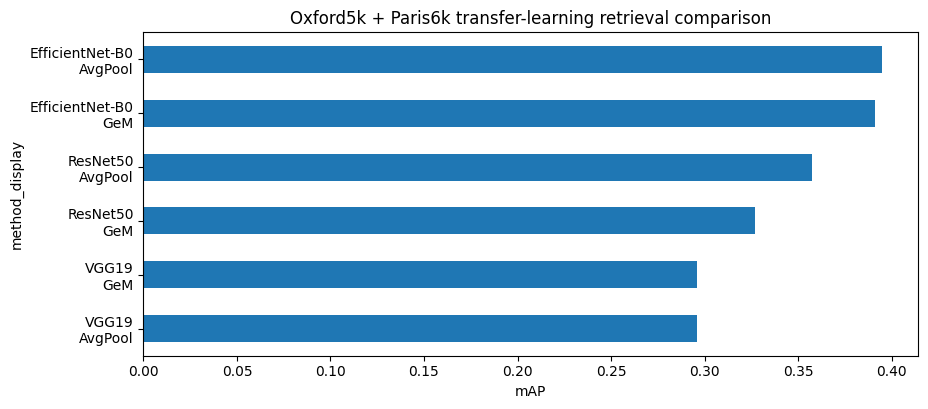

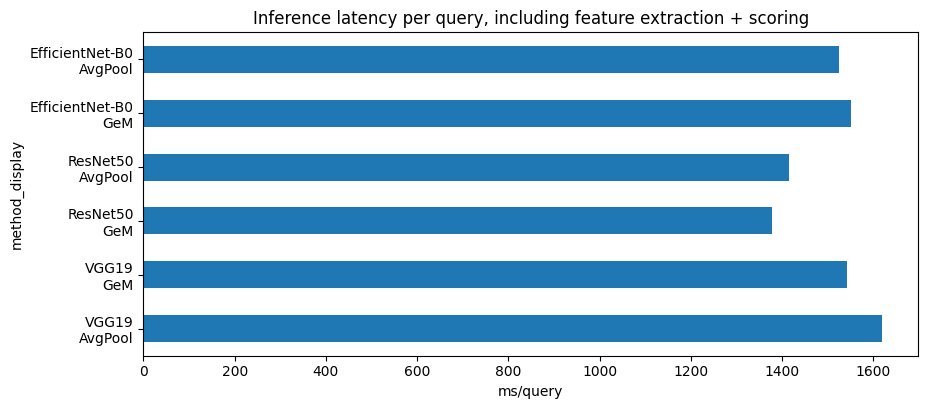

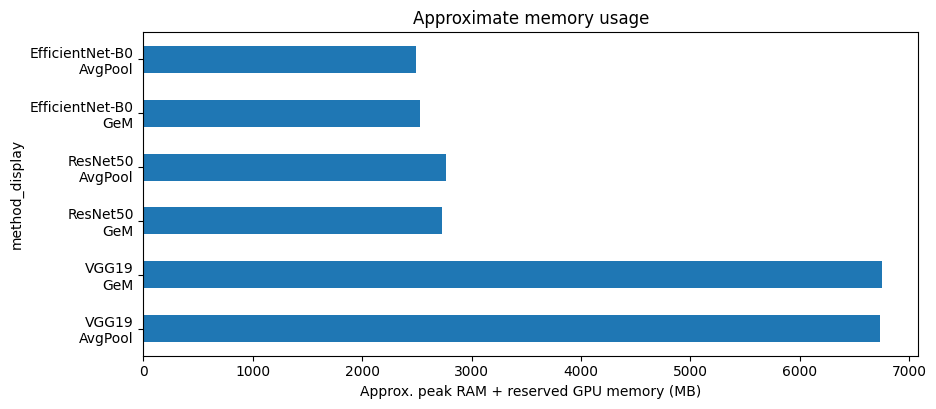

In [10]:
results_df = pd.DataFrame(results)

def clean_method_label(name: str, line_break: str = "\n") -> str:
    """
    Convert long internal method names into compact table/plot labels.

    Example:
        "ResNet50 + AvgPool transfer embeddings" -> "ResNet50\nAvgPool"
        "ResNet50 + GeM(p=3) transfer embeddings" -> "ResNet50\nGeM"
    """
    label = str(name).replace(" transfer embeddings", "").strip()
    label = label.replace(f"GeM(p={GEM_P:g})", "GeM")
    parts = [p.strip() for p in label.split("+")]
    return line_break.join(parts)

if not results_df.empty:
    # Keep the original method name for reproducibility, but add a clean display label
    # for tables and plots.
    results_df["method_display"] = results_df["method"].apply(lambda x: clean_method_label(x, line_break="\n"))
    results_df["method_display_html"] = results_df["method"].apply(lambda x: clean_method_label(x, line_break="<br>"))

    metric_cols = [
        "mAP", "P@1", "P@5", "P@10", "R@1", "R@5", "R@10", f"F1@{F1_K}",
        "inference_latency_ms_per_query", "seconds",
        "memory_usage_mb", "peak_ram_mb", "peak_gpu_allocated_mb", "peak_gpu_reserved_mb",
    ]
    metric_cols = [c for c in metric_cols if c in results_df.columns]

    table_df = (
        results_df
        .sort_values("mAP", ascending=False)
        .reset_index(drop=True)
        .copy()
    )
    table_df = table_df.rename(columns={"method_display_html": "Method"})

    table_cols = ["Method"] + metric_cols
    table_cols = [c for c in table_cols if c in table_df.columns]

    # HTML display is used so the method name can be shown on two lines:
    # ResNet50<br>AvgPool instead of ResNet50 + AvgPool.
    from IPython.display import HTML, display

    numeric_formatters = {
        c: (lambda x: "" if pd.isna(x) else f"{x:.4f}")
        for c in metric_cols
        if c in table_df.columns
    }
    html_table = table_df[table_cols].to_html(
        index=False,
        escape=False,
        formatters=numeric_formatters,
        border=0,
        classes="clean-results-table",
    )
    html_table = f"""
    <style>
    table.clean-results-table {{
        border-collapse: collapse;
        font-size: 13px;
    }}
    table.clean-results-table th, table.clean-results-table td {{
        border: 1px solid #dddddd;
        padding: 6px 8px;
        text-align: center;
        vertical-align: middle;
    }}
    table.clean-results-table th {{
        background-color: #b89393;
        font-weight: 700;
    }}
    table.clean-results-table td:first-child {{
        font-weight: 600;
        white-space: nowrap;
    }}
    </style>
    {html_table}
    """
    display(HTML(html_table))

    out_csv = WORKDIR / "oxford_paris_transfer_learning_results.csv"
    # Save both raw and clean method labels.
    results_df.drop(columns=["method_display_html"], errors="ignore").to_csv(out_csv, index=False)
    print("Saved results to:", out_csv)

    plot_df = results_df.set_index("method_display").sort_values("mAP", ascending=True)

    ax = plot_df[["mAP"]].plot(kind="barh", figsize=(10, max(4, 0.7 * len(plot_df))), legend=False)
    ax.set_xlabel("mAP")
    ax.set_title("Oxford5k + Paris6k transfer-learning retrieval comparison")
    plt.show()

    ax = plot_df[["inference_latency_ms_per_query"]].plot(kind="barh", figsize=(10, max(4, 0.7 * len(plot_df))), legend=False)
    ax.set_xlabel("ms/query")
    ax.set_title("Inference latency per query, including feature extraction + scoring")
    plt.show()

    ax = plot_df[["memory_usage_mb"]].plot(kind="barh", figsize=(10, max(4, 0.7 * len(plot_df))), legend=False)
    ax.set_xlabel("Approx. peak RAM + reserved GPU memory (MB)")
    ax.set_title("Approximate memory usage")
    plt.show()
else:
    print("No results yet.")

## 8. Visualize top retrieved results


Available methods:
- ResNet50 + AvgPool transfer embeddings
- ResNet50 + GeM(p=3) transfer embeddings
- EfficientNet-B0 + AvgPool transfer embeddings
- EfficientNet-B0 + GeM(p=3) transfer embeddings
- VGG19 + AvgPool transfer embeddings
- VGG19 + GeM(p=3) transfer embeddings


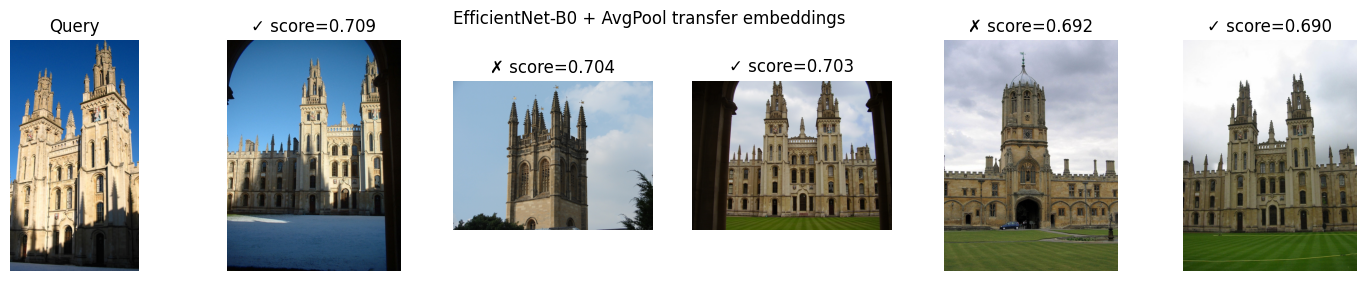

In [9]:
def show_top_results(query_id: int, scores: np.ndarray, title: str, top_k: int = 5):
    gt = query_gt[query_id]
    rel = gt["relevant"]
    junk = gt["junk"]
    order = ranked_indices_without_junk(scores[query_id], junk)[:top_k]

    plt.figure(figsize=(3 * (top_k + 1), 3))
    plt.subplot(1, top_k + 1, 1)
    plt.imshow(Image.open(q_paths[query_id]))
    plt.title("Query")
    plt.axis("off")

    for j, idx in enumerate(order, start=2):
        plt.subplot(1, top_k + 1, j)
        plt.imshow(Image.open(db_paths[idx]))
        mark = "✓" if idx in rel else "✗"
        plt.title(f"{mark} score={scores[query_id, idx]:.3f}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

print("Available methods:")
for name in scores_by_method:
    print("-", name)

if scores_by_method:
    method_name = max(results, key=lambda r: r["mAP"])["method"]
    show_top_results(query_id=0, scores=scores_by_method[method_name], title=method_name, top_k=5)